# 16 - the steel reserve and flaring

Until now a Steelpush burned forever: infinite metal, one fixed strength.
Real Allomancy spends metal. A Coinshot carries a finite supply of steel,
burns it down while pushing, and can FLARE it - burn harder for a bigger
push at the cost of faster consumption. This notebook adds both and finds
out what flaring is actually good for.

The model (stated in sim/steelpush.py): a push now has steel_grams (the
supply, defaulting to unlimited so nothing earlier changes), a base
burn_grams_per_second, and a flare multiplier. Two modeling choices,
grounded where canon is clear and flagged where it is not:

- Burning is flesh-bound chemistry, so it runs on the Coinshot's LOCAL
  clock - a Coinshot inside a bendalloy bubble burns through their metal
  faster in world time, exactly like healing and poison (notebooks 04, 06).
- Flaring multiplies the push by `flare` but the burn rate by `flare`
  SQUARED. Canon says flaring burns brighter for more power, faster; the
  square is our cost curve, and the whole point of this notebook is to show
  what that curve costs.

Terms used in this notebook, defined once:

- **Reserve**: the Coinshot's steel supply, in grams.
- **Burn rate**: grams of steel consumed per second while the flame is lit.
- **Flare**: a multiplier (>= 1) for burning harder - more push, faster burn.
- **Push-seconds**: peak push force times how long the metal lasts. A fair
  measure of the total push you get out of a given reserve.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt

from sim import Body, World, Steelpush, GRAVITY_M_PER_S2


def push_against_anchor(steel_grams, burn_grams_per_second, flare=1.0,
                        seconds=12.0):
    """Wax holding station on a fixed anchor with a finite steel supply.
    Returns time, Wax height, and reserve over the run."""
    world = World()
    wax = world.add_body(Body("wax", 80, (0, 1.0)))
    anchor = world.add_body(Body("anchor", 0.004, (0, 0.05), radius_m=0.01,
                                 is_metal=True, is_fixed=True))
    push = world.add_power(Steelpush(wax, anchor, 2000, steel_grams=steel_grams,
                                     burn_grams_per_second=burn_grams_per_second,
                                     flare=flare))
    push.active = True
    reserve = []
    for _ in range(int(seconds / world.dt_seconds)):
        world.step()
        reserve.append(push.steel_grams)
    data = world.history.body("wax")
    return np.array(data["t"]), np.array(data["y"]), np.array(reserve)

## Experiment A - the reserve runs dry

Give Wax 2 grams of steel and a burn rate of 0.5 g/s, and have him push.
Paper prediction: the metal lasts 2 / 0.5 = 4 seconds. While it burns, the
steady push launches Wax into the same undamped bob as notebook 15 (no
damping, so he swings rather than holding still); at 4 s the flame dies
mid-swing, the push vanishes, and he falls the rest of the way to the
ground.

2 g at 0.5 g/s: metal gone at t = 4.00 s
Wax peaks at 19.0 m, then falls to 0.3 m once the push dies


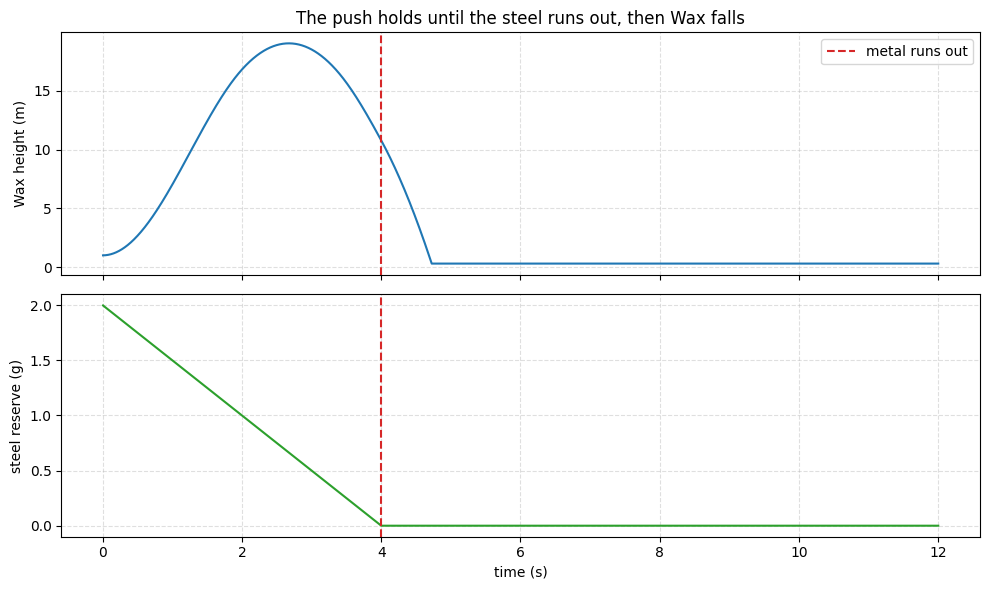

In [2]:
t, y, reserve = push_against_anchor(steel_grams=2.0, burn_grams_per_second=0.5)
empty_at = t[np.argmax(reserve <= 0.0)]
print(f"2 g at 0.5 g/s: metal gone at t = {empty_at:.2f} s")
print(f"Wax peaks at {y.max():.1f} m, then falls to {y[-1]:.1f} m once the push dies")

figure, (height_axes, reserve_axes) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
height_axes.plot(t, y, color="tab:blue")
height_axes.axvline(empty_at, color="tab:red", linestyle="--", label="metal runs out")
height_axes.set_ylabel("Wax height (m)")
height_axes.set_title("The push holds until the steel runs out, then Wax falls")
height_axes.legend()
height_axes.grid(True, linestyle="--", alpha=0.4)
reserve_axes.plot(t, reserve, color="tab:green")
reserve_axes.axvline(empty_at, color="tab:red", linestyle="--")
reserve_axes.set_xlabel("time (s)")
reserve_axes.set_ylabel("steel reserve (g)")
reserve_axes.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Experiment B - what flaring costs

Flaring multiplies the push by `flare` and the burn by `flare` squared. So
a harder flare gives a bigger shove but empties the reserve much faster.
The question worth answering: is flaring just 'more', or does it cost you?

We sweep the flare on a fixed 2 g reserve and measure three things: the peak
push force, how long the metal lasts, and their product - the push-seconds
the reserve delivers. Paper prediction: peak force rises with flare, burn
time falls as 1/flare squared, so push-seconds fall as 1/flare. Flaring
should buy peak power at the price of total push.

flare  peak push (N)  metal lasts (s)   push-seconds
    1           1881             4.00           7525
    2           3762             1.00           3778
    3           5644             0.45           2516
    4           7525             0.25           1881


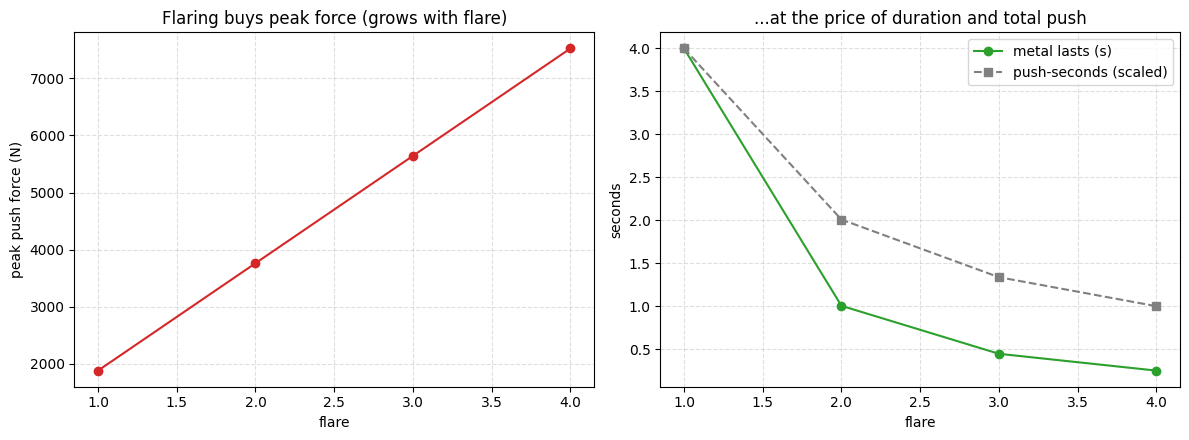

In [3]:
def peak_force(flare):
    world = World()
    wax = world.add_body(Body("wax", 80, (0, 1.0)))
    anchor = world.add_body(Body("anchor", 0.004, (0, 0.05), radius_m=0.01,
                                 is_metal=True, is_fixed=True))
    push = world.add_power(Steelpush(wax, anchor, 2000, flare=flare))
    push.active = True
    world.step()
    return 80 * wax.velocity[1] / world.dt_seconds + 80 * GRAVITY_M_PER_S2

def seconds_to_empty(flare):
    t, y, reserve = push_against_anchor(2.0, 0.5, flare=flare, seconds=12.0)
    return t[np.argmax(reserve <= 0.0)]

flares = [1, 2, 3, 4]
peaks = [peak_force(f) for f in flares]
lives = [seconds_to_empty(f) for f in flares]
push_seconds = [p * L for p, L in zip(peaks, lives)]

print(f"{'flare':>5}  {'peak push (N)':>13}  {'metal lasts (s)':>15}  {'push-seconds':>13}")
for f, p, L, ps in zip(flares, peaks, lives, push_seconds):
    print(f"{f:5d}  {p:13.0f}  {L:15.2f}  {ps:13.0f}")

figure, (force_axes, life_axes) = plt.subplots(1, 2, figsize=(12, 4.5))
force_axes.plot(flares, peaks, "o-", color="tab:red")
force_axes.set_xlabel("flare")
force_axes.set_ylabel("peak push force (N)")
force_axes.set_title("Flaring buys peak force (grows with flare)")
force_axes.grid(True, linestyle="--", alpha=0.4)
life_axes.plot(flares, lives, "o-", color="tab:green", label="metal lasts (s)")
life_axes.plot(flares, [ps / push_seconds[0] * lives[0] for ps in push_seconds],
               "s--", color="gray", label="push-seconds (scaled)")
life_axes.set_xlabel("flare")
life_axes.set_ylabel("seconds")
life_axes.set_title("...at the price of duration and total push")
life_axes.legend()
life_axes.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

The numbers match the prediction. Peak force doubles, triples, quadruples
with the flare (1881, 3762, 5644, 7525 N). The metal lasts 4 s, 1 s, 0.44 s,
0.25 s - falling as 1/flare squared. And the push-seconds, the total push
the 2 g delivers, fall as 1/flare: flaring to 4 leaves you a quarter of the
push-seconds you would have had cruising. So flaring is a burst weapon -
when you need a wall of force right now, you spend metal recklessly for it,
and you get less total work out of the same steel. You never flare to fly
across a city; you flare to not die in the next half second.

(The push-seconds here use the peak force times the burn time - an
idealization, since the real force eases as Wax moves out of point-blank
range. It is a fair efficiency measure because both factors are clean.)

## Findings

1. **Steel is now a spent resource.** A finite reserve burns down while the
   flame is lit and the push dies at zero (2 g at 0.5 g/s holds Wax for
   exactly 4 s, then he falls). Unlimited reserve stays the default, so
   notebooks 02 and 14 and 15 and every push probe are unchanged (verified).
2. **Flaring is a burst, not a cruise.** Peak push grows with the flare;
   the metal lasts as 1/flare squared; the total push delivered falls as
   1/flare. Flare 4 gives four times the shove for a quarter of the total
   work from the same steel. Worth it to survive a moment, wasteful for
   travel.
3. **Burning runs on the local clock** (modeling choice, stated). A Coinshot
   who flares inside a bendalloy bubble empties their metal far faster in
   world time, because the burn keeps their sped-up local pace - the same
   rule that accelerates healing and poison. A standing prediction worth a
   future experiment: speed-bubble fighting is metal-hungry.
4. **Open canon question.** The flare-squared cost curve is ours, not
   Brandon's; whether flaring really loses efficiency, and by how much, is
   the kind of thing the verbose Coinshot battles could pin down with a
   searchable text. Filed for the canon-research layer.

Probes: check_steel_reserve_runs_dry, check_flaring_trades_push_for_metal.

This closes the steel-robustness arc (notebooks 14-16): multi-target
pushing, the hover oscillator, and the metal budget. The reserve also lays
the groundwork for duralumin, which dumps the whole reserve in one tick.